# Line Diagnostics and Wavelength Calibration

This notebook introduces two related skillsets: measuring line diagnostics for an individual emission line and establishing a wavelength calibration for a spectrograph. Here, we'll work with an extracted HeNeAr emission line spectrum from the SBO 24" spectrograph, focusing first on an individual line and then on tying all the lines together into a coherent model for the relationship between pixel and wavelength. 

In [1]:
# do some basic imports
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.table import QTable

# make matplotlib plots play nicely with astropy units
from astropy.visualization import quantity_support
quantity_support();

## Load a HeNeAr Wavelength Calibration Spectrum

Let's load an example 1D spectrum from the SBO spectrograph into a data table. This spectrum was produced by averaging together a few rows from the center of a 2D spectrograph image. As we read it here, `astropy` units are attached to each column. 

In [2]:
uncalibrated = QTable.read('sbo-example-HeNeAr.ecsv', format='ascii.ecsv')
uncalibrated

wavelength_pixel,flux,uncertainty
pix,ph / (pix s),ph / (pix s)
float64,float64,float64
0.0,0.133,1.0296931678903185
1.0,-0.931,0.7268204867778562
2.0,1.729,1.3631830471363704
3.0,-1.064,0.6795351499370726
4.0,0.399,1.092368078991692
5.0,-0.798,0.7712120460677464
6.0,-0.798,0.7712120460677464
7.0,2.926,1.5674080579096177


This spectrum has the wavelength dimension still in units of pixels, representing the column along the detector. By the end of this notebook, we'll convert these pixels into actual wavelengths.

In [3]:
uncalibrated['wavelength_pixel']

<Quantity [0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 1.1653e+04, 1.1654e+04,
           1.1655e+04] pix>

The flux, and uncertainty, are expressed as a photon rate, in units of $\sf photons/s/pixel$. Because the HeNeAr do not emit much continuum between the strong emission lines, the spectrum is consistent with zero over many pixels, with uncertainties scattering it above and below.

In [4]:
uncalibrated['flux']

<Quantity [ 0.133, -0.931,  1.729, ..., -0.931, -0.665,  0.266] ph / (pix s)>

This particular file also has a little bit of metadata added summarizing a few basic details of the observation, including the grating tilt and slit width for this particular exposure.

In [5]:
uncalibrated.meta

{'telescope': 'Sommers-Bausch Observatory Leto (24")',
 'grating-tilt': 'about -10 degrees',
 'slit-width': '20 microns',
 'focus': 'probably not great',
 'lamp(s)': 'HeNeAr'}

This spectrum is "uncalibrated" in the sense that the wavelength axis is still in units of pixels. Let's plot the spectrum, and we'll use the `%matplotlib ipympl` magic command to make the plots be interactive, so we can zoom in.

In [6]:
%matplotlib ipympl

Let's first plot the spectrum on a linear scale. 

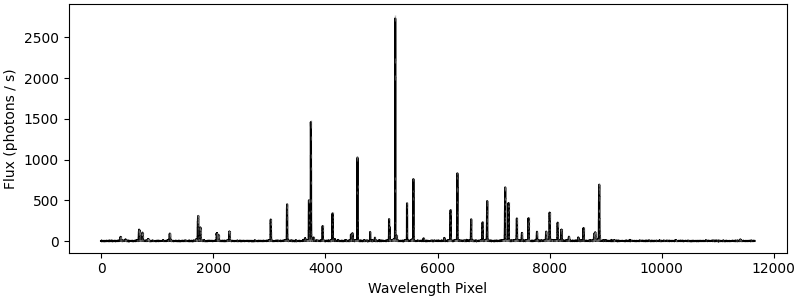

In [7]:
def plot_spectrum_from_table(table):
    ''' 
    A quick wrapper to plot an uncalibrated spectrum from a table. 
    '''

    # extract the arrays we need
    pixel = uncalibrated['wavelength_pixel']
    flux = uncalibrated['flux']
    uncertainty = uncalibrated['uncertainty']

    # plot the spectrum
    plt.step(pixel, flux, where='mid', color='black')
    plt.errorbar(pixel, flux, uncertainty, linewidth=0, elinewidth=1, color='gray', alpha=0.5)
    plt.xlabel('Wavelength Pixel')
    plt.ylabel('Flux (photons / s)')

plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum_from_table(uncalibrated);

Since there are some very bright lines and some much fainter ones, it might help to look at this on a log scale. Here the uncertainties will look a little funny in places where the flux is close enough to zero that the errorbar might stretch to negative values. However, we can see many more of the real spectral lines at once.

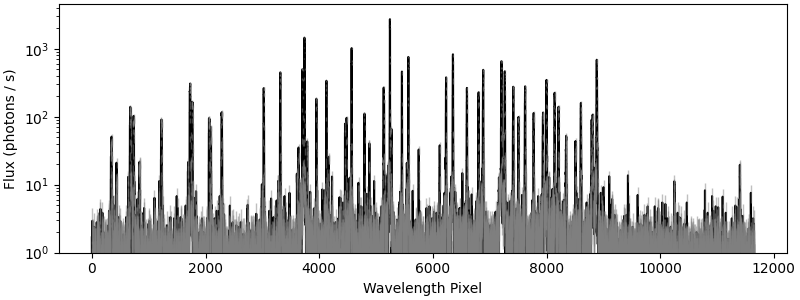

In [8]:
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum_from_table(uncalibrated)
plt.yscale('log')
plt.ylim(1, None);

## Focusing on One Line

Let's try to measure some basic line diagnostics for one line in this emission specturm. We'll use [`specutils`](https://specutils.readthedocs.io/en/stable/) to do this, which is full of tools for spectrum analysis and modeling. To do so, we'll need to start by converting our data table into a `specutils.Spectrum` object.

In [9]:
from specutils import Spectrum
from astropy.nddata import StdDevUncertainty

# create a specutils "Spectrum" object, including uncertainty that can be propagated
spectrum = Spectrum(spectral_axis=uncalibrated['wavelength_pixel'], 
                    flux=uncalibrated['flux'],
                    uncertainty=StdDevUncertainty(uncalibrated['uncertainty']))

spectrum

<Spectrum(flux=[0.133 ... 0.266] ph / (pix s) (shape=(11656,), mean=9.49298 ph / (pix s)); spectral_axis=<SpectralAxis [0.0000e+00 1.0000e+00 2.0000e+00 ... 1.1653e+04 1.1654e+04 1.1655e+04] pix> (length=11656); uncertainty=StdDevUncertainty)>

This spectrum object still has no wavelength calibration, so the `spectral_axis` is still in units of pixels. Let's write another little wrapper to be able to plot `Spectrum` objects like this.

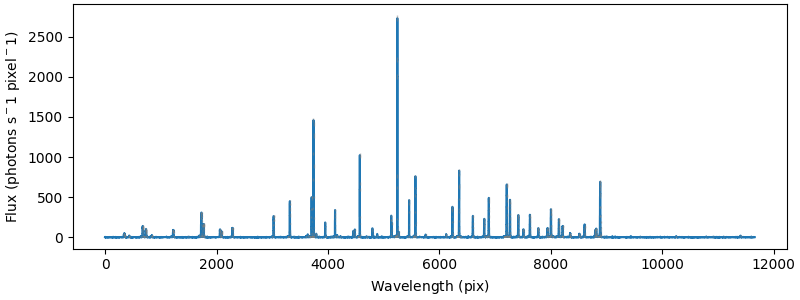

In [10]:
def plot_spectrum(spectrum, **kw):
    '''
    Make a plot of a specutils.Spectrum object.

    Parameters 
    ----------
    spectrum : specutils.Spectrum
        The main input should be a spectrum stored 
        as a `specutils` object, with `.spectral_axis`
        and `.flux` attributes attached.
    **kw : dict 
        All other keywords will be passed into the 
        `plt.step` plotting function. 
    '''

    # extract the arrays we need
    x = spectrum.spectral_axis
    flux = spectrum.flux
    uncertainty = spectrum.uncertainty.quantity

    # plot the spectrum
    plt.step(x, flux, where='mid', **kw)
    plt.errorbar(x, flux, uncertainty, linewidth=0, elinewidth=1, color='gray', alpha=0.5)

    # add some labels
    plt.xlabel(f'Wavelength ({x.unit.to_string(format="latex_inline")})')
    plt.ylabel('Flux (photons s$^-1$ pixel$^-1$)')

plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum)

Let's pick the line around wavelength pixel number $\sf w=8885~pixels$. We'll use `SpectralRegion` and `extract_region` to extract a small subregion, just centered on that line. By looking a subregion, we can fit just the line itself and the immediately surrounding pixels; we don't need to worry about other lines across the spectrum.

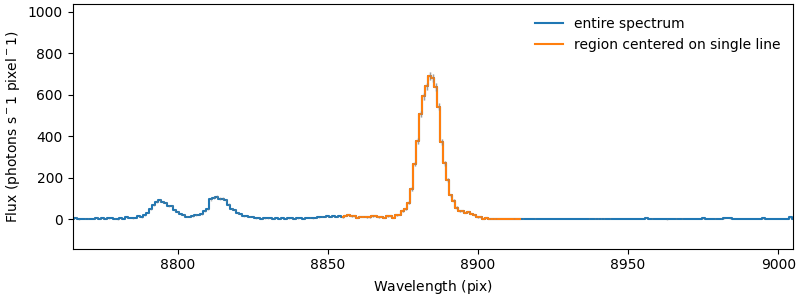

In [11]:
from specutils import SpectralRegion
from specutils.manipulation import extract_region

# define the pixels on which we want to focus
line_pixel = 8885*u.pixel
window = 30*u.pixel

# make a tiny sub-spsectrum from that region
sub_region = SpectralRegion(line_pixel - window, line_pixel + window)
sub_spectrum = extract_region(spectrum, sub_region)

# plot the region over the overall spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum, label='entire spectrum')
plot_spectrum(sub_spectrum, label='region centered on single line')
plt.legend(frameon=False)
plt.xlim(line_pixel - window*4, line_pixel + window*4)
plt.ylim(None, np.max(sub_spectrum.flux)*1.5);


Just like any `Spectrum` object, we can access the data in this "sub-spectrum" centered just on the line via the `.spectral_axis` and `.flux` attributes.

In [12]:
sub_spectrum.spectral_axis

<SpectralAxis [8855., 8856., 8857., 8858., 8859., 8860., 8861., 8862., 8863., 8864.,
   8865., 8866., 8867., 8868., 8869., 8870., 8871., 8872., 8873., 8874.,
   8875., 8876., 8877., 8878., 8879., 8880., 8881., 8882., 8883., 8884.,
   8885., 8886., 8887., 8888., 8889., 8890., 8891., 8892., 8893., 8894.,
   8895., 8896., 8897., 8898., 8899., 8900., 8901., 8902., 8903., 8904.,
   8905., 8906., 8907., 8908., 8909., 8910., 8911., 8912., 8913., 8914.] pix>

In [13]:
sub_spectrum.flux

<Quantity [ 1.01080e+01,  1.68910e+01,  1.78220e+01,  1.55610e+01,
            1.31670e+01,  6.38400e+00,  1.15710e+01,  1.13050e+01,
            8.91100e+00,  8.11300e+00,  1.51620e+01,  1.43640e+01,
            9.31000e+00,  1.22360e+01,  7.71400e+00,  1.39650e+01,
            1.29010e+01,  5.32000e+00,  1.83540e+01,  2.15460e+01,
            3.79050e+01,  4.84120e+01,  7.86030e+01,  1.46167e+02,
            2.65468e+02,  3.75725e+02,  5.06331e+02,  5.91318e+02,
            6.39597e+02,  6.90403e+02,  6.80428e+02,  6.37070e+02,
            5.41443e+02,  3.71868e+02,  2.69591e+02,  1.88328e+02,
            1.15311e+02,  8.81790e+01,  5.57270e+01,  4.00330e+01,
            3.81710e+01,  3.19200e+01,  3.47130e+01,  2.69990e+01,
            1.98170e+01,  9.57600e+00,  1.02410e+01,  1.33000e+00,
            3.59100e+00,  1.72900e+00,  2.52700e+00,  2.66000e+00,
            6.65000e-01,  1.46300e+00,  1.33000e-01,  6.65000e-01,
           -2.66000e-01,  2.92600e+00,  7.98000e-01,  7.98000e

## Line Diagnostics from `specutils.analysis`

Let's start using the tools in `specutils.analysis` to measure a few key line diagnostics. Here, we will try to measure...

- the line centroid
- the line integrated flux
- various metics of the line width

Let's calculate the *line centroid*, the center of the line. You'll notice the centroid calculated below is in fracitonal pixels; that's because the flux-weighted centroid algorithm is averaging together information from multiple pixels, getting position precision that can be finer even than an individual pixel.

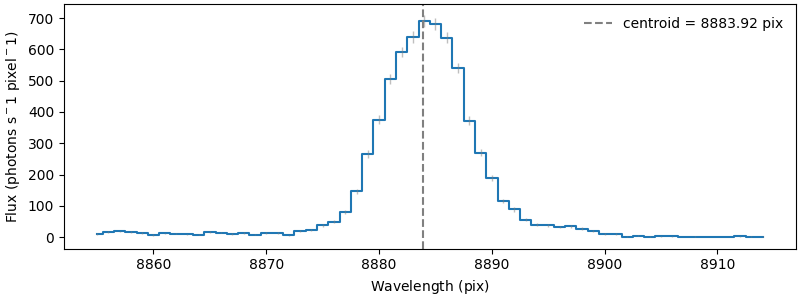

In [14]:
from specutils.analysis import centroid

# calculate the flux-weight centroid of the region sub-spectrum
this_line_centroid = centroid(sub_spectrum)

# plot the centroid
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')
plt.legend(frameon=False);

Let's calculate the *line flux*, the total flux in the line, integrated over all pixels. If the flux is in units of $\sf photons/s/pixel$ and the spectral axis is in units of $\sf pixels$, then the integrated flux will be in units of $\sf photons/s$. In this example, if we back-of-the-envelope estimate a height of $\sf 700~photons/s/pixel$ and a width of $\sf 10~pixels$, it should make sense that the integral works out to about $\sf 7000~photons/s$.

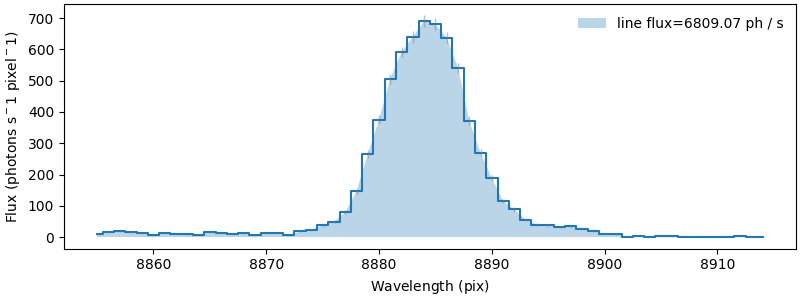

In [15]:
from specutils.analysis import line_flux

# calculate the line flux
this_line_flux = line_flux(sub_spectrum)

# plot the line flux
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'line flux={this_line_flux:.2f}')
plt.legend(frameon=False);

Finally, let's calculate a few estimates of the line width. There are a couple methods we might use:
- `fwhm` = the full-width at half-maximum ($\sf FWHM$), calculated numerically, regardless of the shape of the line
- `fwzi` = the full-width at zero-intensity, where the line first drops to zero (with noise, this can be a bit less stable than the $\sf FWHM$)

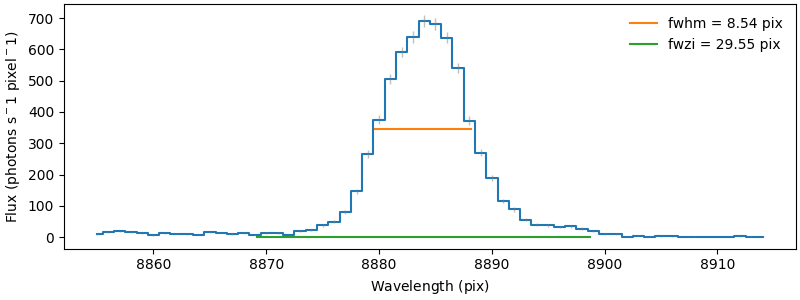

In [16]:
from specutils.analysis import fwhm, fwzi

# calculate various types of line width
this_line_fwhm = fwhm(sub_spectrum)
this_line_fwzi = fwzi(sub_spectrum)

plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")

# draw a line for the FWZI
x = this_line_centroid + [-0.5,0.5]*this_line_fwzi
y = np.zeros(2)
plt.plot(x, y, label=f"fwzi = {this_line_fwzi:.2f}")

plt.legend(frameon=False);

Let's put these all together into one plot:

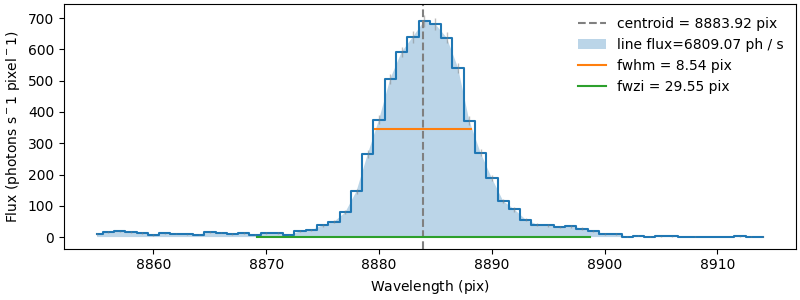

In [17]:
from specutils.analysis import centroid

# calculate the flux-weight centroid of the region sub-spectrum
this_line_centroid = centroid(sub_spectrum)

# calculate the line flux
this_line_flux = line_flux(sub_spectrum)

# calculate various types of line width
this_line_fwhm = fwhm(sub_spectrum)
this_line_fwzi = fwzi(sub_spectrum)

# plot the centroid
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'line flux={this_line_flux:.2f}')

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")

# draw a line for the FWZI
x = this_line_centroid + [-0.5,0.5]*this_line_fwzi
y = np.zeros(2)
plt.plot(x, y, label=f"fwzi = {this_line_fwzi:.2f}")

plt.legend(frameon=False);

## Line Modeling with `specutils.fitting`

The above [`specutils.analysis`](https://specutils.readthedocs.io/en/stable/analysis.html) tools can be a very quick and handy way to estimate the basic properties of a line. If you want to do more nuanced modeling of line shapes, you might want to dive into [`specutils.fitting`](https://specutils.readthedocs.io/en/stable/fitting.html#line-spectrum-fitting). We'll show a very brief version of that here, but refer you to the documentation for oodles more details and options. 

Here, we set an initial guess for a modeled Gaussian, and then we optimize the parameters (the `mean`, the `amplitude`, the `stddev`) of that model. In general, this approach can be fairly sensitive to the initial conditions -- if you set your guess a little too far away or a little too wide, it might not converge to the right answer! 

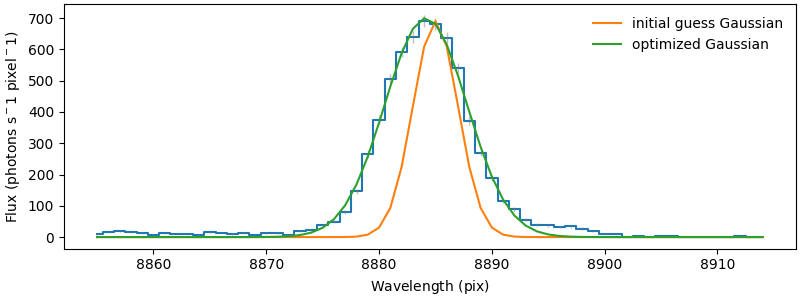

In [18]:
from specutils.fitting import estimate_line_parameters, fit_lines
from astropy.modeling import models

# define an initial guess for the Gaussian line model
gaussian_initial_guess = models.Gaussian1D(mean=line_pixel, stddev=2*u.pix, amplitude=np.max(sub_spectrum.flux))

# optimize the parameters of that initial guess
gaussian_optimized = fit_lines(sub_spectrum, gaussian_initial_guess)

# plot the spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# plot the initial guess model
plt.plot(sub_spectrum.spectral_axis, gaussian_initial_guess(sub_spectrum.spectral_axis), label=f'initial guess Gaussian')

# plot the optimized model 
plt.plot(sub_spectrum.spectral_axis, gaussian_optimized(sub_spectrum.spectral_axis), label=f'optimized Gaussian')
plt.legend(frameon=False);


Let's try to put this Gaussian fit all together, in a way that we can compare with the `specutils.analysis` approach way above. To directly compare, we'll rely on a neat mathematical result that the FWHM of a Gaussian with width $\sf \sigma$ is $\sf FWHM = 2\sqrt{2\ln 2} \sigma$, to express the fitted standard deviation of the Gaussian on comparable footing to the FWHM above.

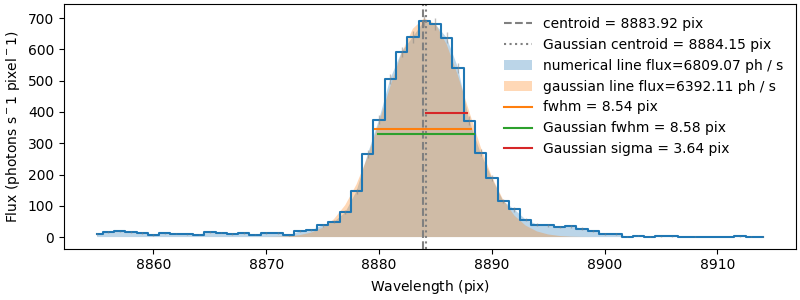

In [19]:
# plot the spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# extract the optimized model parameters
gaussian_line_centroid = gaussian_optimized.mean.quantity
gaussian_line_sigma = gaussian_optimized.stddev.quantity
gaussian_line_amplitude = gaussian_optimized.amplitude.quantity

# calculate integrated line flux from the integral of a Gaussian
gaussian_line_flux = gaussian_line_amplitude*np.sqrt(2*np.pi*gaussian_line_sigma**2)
gaussian_line_fwhm = gaussian_optimized.fwhm

# plot the centroid
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')
plt.axvline(gaussian_line_centroid, color='gray', linestyle=':', label=f'Gaussian centroid = {gaussian_line_centroid:.2f}')

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'numerical line flux={this_line_flux:.2f}')
plt.fill_between(sub_spectrum.spectral_axis, gaussian_optimized(sub_spectrum.spectral_axis), alpha=0.3, label=f'gaussian line flux={gaussian_line_flux:.2f}')

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")
x = gaussian_line_centroid + [-0.5,0.5]*gaussian_line_fwhm
plt.plot(x, y*.95, label=f"Gaussian fwhm = {gaussian_line_fwhm:.2f}")

# draw a line for the FWHM
x = gaussian_line_centroid + [0,1]*gaussian_line_sigma
y = np.exp(-0.5)*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y*.95, label=f"Gaussian sigma = {gaussian_line_sigma:.2f}")

plt.legend(frameon=False);

Gosh, this example got a little complicated, but now you have two handy methods for estimating line diagnostics for emission lines! 

*Please note that the approaches shown here rely on the spectrum either not having a continuum.* If your spectrum does have some significant continuum, consider subtracting it using some kind of [continuum fit](https://specutils.readthedocs.io/en/stable/fitting.html#continuum-fitting).

## Fit Lots of Lines

To fit a wavelength calibration, we're going to need to estimate the centroids of as many emission lines as possible. Fortunately, `specutils` has some handy tools for [finding emission lines](https://specutils.readthedocs.io/en/stable/fitting.html#line-finding); here we'll use `find_lines_derivative` to identify peaks from zero-crossings in the derivative, for lines with flux above some threshold.

In [20]:
from specutils.fitting import find_lines_derivative

# generate intital guesses for the positions of many lines
lots_of_lines = find_lines_derivative(spectrum, flux_threshold=10*u.photon/u.s/u.pixel)
lots_of_lines


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


line_center,line_type,line_center_index
pix,,
float64,str8,int64
337.0,emission,337
341.0,emission,341
347.0,emission,347
640.0,emission,640
676.0,emission,676
696.0,emission,696
727.0,emission,727
734.0,emission,734


Now that we have initial guesses, we can loop through each line and refine our estimates of the line centers from these rough integer values to more precise centroids. 

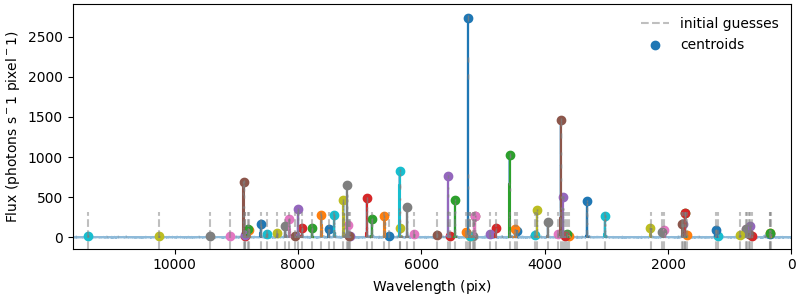

In [21]:
plt.figure(figsize=(8, 3), constrained_layout=True)

# how wide around each line guess should consider for a centroid?
line_centroiding_window = 10*u.pixel

# create some empty columns in the table of lines
lots_of_lines['centroid'] = np.nan*u.pixel
lots_of_lines['fwhm'] = np.nan*u.pixel
lots_of_lines['flux'] = np.nan*u.photon/u.s
lots_of_lines['peak'] = np.nan*u.photon/u.s/u.pixel

# loop through lines
for i in range(len(lots_of_lines)):

    # start from an initial guess   
    line_guess = lots_of_lines['line_center'][i]

    # extract a region around the line
    sub_region = SpectralRegion(line_guess - line_centroiding_window, line_guess + line_centroiding_window)
    sub_spectrum = extract_region(spectrum, sub_region)
    
    # extract some line diagnostics (which won't be perfect for blended lines)
    this_centroid = centroid(sub_spectrum)
    this_fwhm = fwhm(sub_spectrum)
    this_flux = line_flux(sub_spectrum)
    this_peak = np.max(sub_spectrum.flux)

    # store them in the table    
    lots_of_lines['centroid'][i] = this_centroid
    lots_of_lines['fwhm'][i] = this_fwhm
    lots_of_lines['flux'][i] = this_flux
    lots_of_lines['peak'][i] = this_peak

    # plot each sub-spectrum + line guess + measured centroid
    plot_spectrum(sub_spectrum)
    if i == 0:
        label = 'initial guesses'
    else:
        label = None
    plt.axvline(line_guess, ymax=0.15, alpha=0.5, linestyle='--', color='gray', label=label)
    if i == 0: 
        label = 'centroids'
    else: 
        label = None
    plt.scatter(this_centroid, this_peak, label=label)


# plot the full spectrum behind, for reference
plot_spectrum(spectrum, alpha=0.5, zorder=-100)
plt.legend(frameon=False, loc='upper right')
plt.xlim(len(uncalibrated), 0);

Take a moment to zoom in on a few lines. Check that you're finding lots of lines, and check that the centroid positions for those lines seem to make sense. If we look at the table below, we'll see that it's now populated with our precisely measured line diagnostics for every line we started with. 

(array([ 1.,  6.,  1., 15.,  8.,  7.,  4., 11.,  6.,  6.,  4.,  3.,  2.,
         5.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29.]),
 <BarContainer object of 29 artists>)

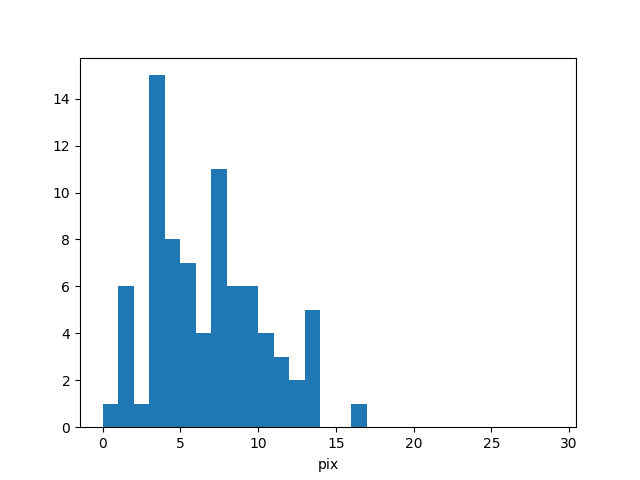

In [22]:
plt.figure()
plt.hist(lots_of_lines['fwhm'], bins=np.arange(0, 30))

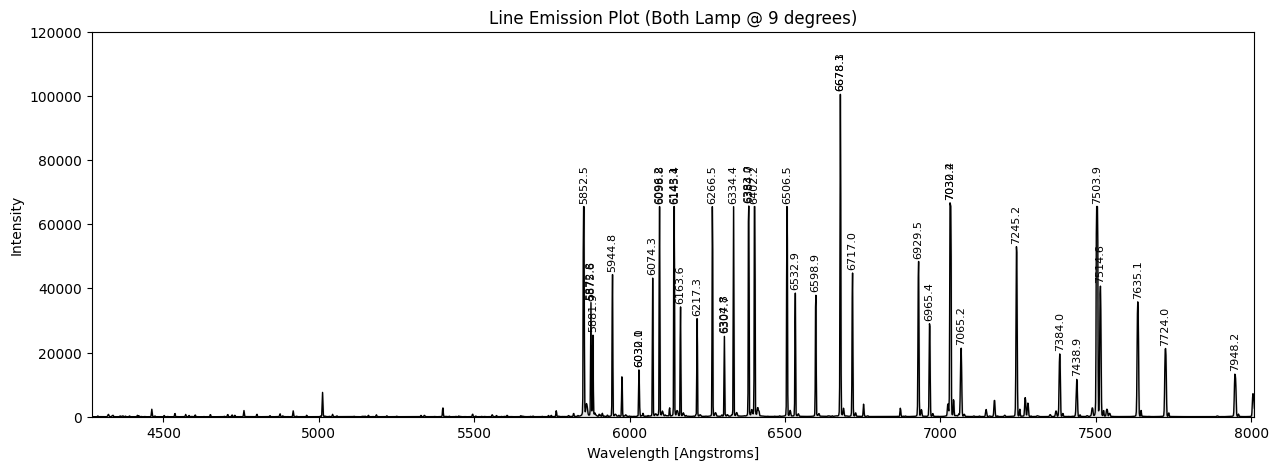

In [23]:
from IPython.display import Image
Image('SBO-wavelength-references/both_9deg_line_emissions.png')

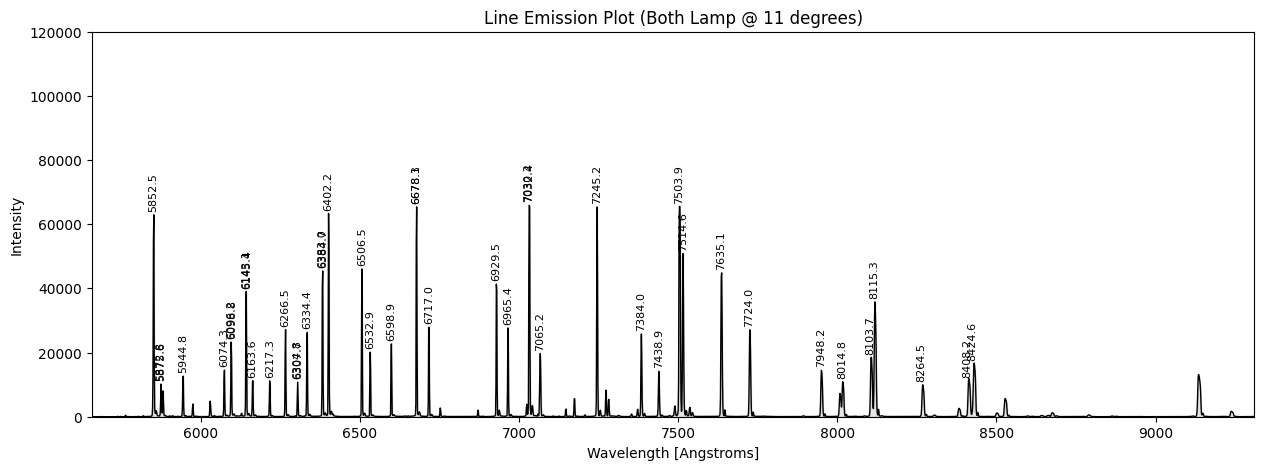

In [24]:
Image('SBO-wavelength-references/both_11deg_line_emissions.png')

In [25]:
'''1224*u.pixel = 8521*u.AA
8885~pixels = 5852.5*u.AA'''

'1224*u.pixel = 8521*u.AA\n8885~pixels = 5852.5*u.AA'

In [26]:
lots_of_lines['manually-matched-wavelength'] = np.nan*u.AA
lots_of_lines['automatically-matched-wavelength'] = np.nan*u.AA

lots_of_lines.add_index('line_center_index')
lots_of_lines.loc.with_index('line_center_index')[8884]['manually-matched-wavelength'] = 5853*u.AA
lots_of_lines.loc.with_index('line_center_index')[4882]['manually-matched-wavelength'] = 7147.04*u.AA
lots_of_lines.loc.with_index('line_center_index')[676]['manually-matched-wavelength'] = 8424.6*u.AA

In [27]:
lots_of_lines.show_in_notebook()

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

In [28]:
known_lines = QTable.read('HeNeAr-lines-at-SBO.ecsv')
reference_wavelengths = known_lines['wavelength']

TimeoutError: [Errno 60] Operation timed out

Model: Polynomial1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Degree: 2
Parameters:
            c0                 c1                     c2          
         Angstrom        Angstrom / pix        Angstrom / pix2    
    ----------------- -------------------- -----------------------
    8622.270521647819 -0.29049080477189415 -2.3882908782881646e-06


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/var/folders/_4/bcdg2gg10bl4p015nxzlhq_40000gp/T/ipykernel_32733/3254275156.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sf \lambda = $ Wavelength ($\AA$)')


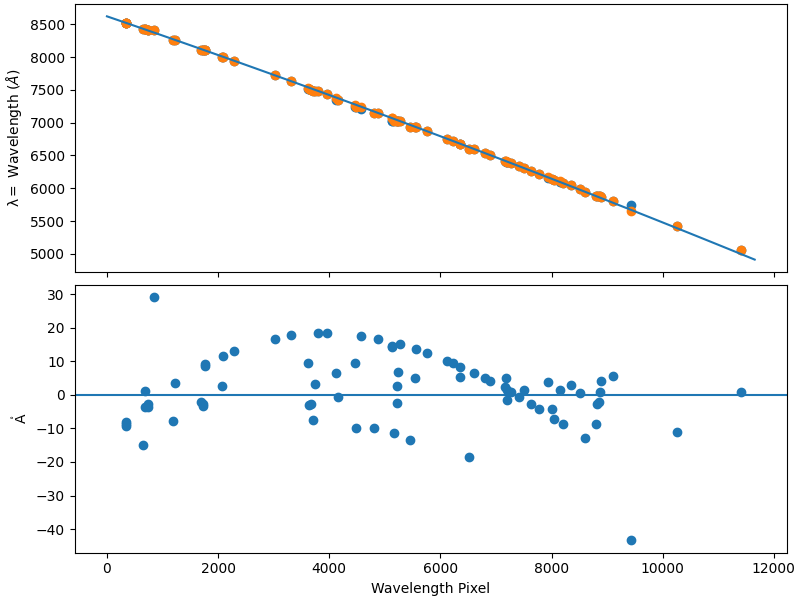

In [ ]:


from astropy.modeling import models, fitting
fit = fitting.LinearLSQFitter()


ok = np.isfinite(lots_of_lines['manually-matched-wavelength'])

initial_wavelength_function = fit(models.Polynomial1D(degree=2), 
                                  lots_of_lines[ok]['centroid'], 
                                  lots_of_lines[ok]['manually-matched-wavelength'])

print(initial_wavelength_function)
fi, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True, constrained_layout=True)


residuals = matched_wavelength - initial_wavelength_function(matched_pixel)
smooth_pixel_grid = np.linspace(np.min(spectrum.spectral_axis), np.max(spectrum.spectral_axis))
plt.sca(ax[0])
plt.ylabel('$\sf \lambda = $ Wavelength ($\AA$)')
plt.scatter(matched_pixel, matched_wavelength)
plt.plot(smooth_pixel_grid, initial_wavelength_function(smooth_pixel_grid))



guess_for_other_lines = wavelength_function(lots_of_lines['centroid'])
wavelength_threshold = 50*u.AA
for i in range(len(reference_wavelengths)):
    distance_to_lines = np.abs(reference_wavelengths - guess_for_other_lines[i])
    i_closest = np.argmin(distance_to_lines)

    if distance_to_lines[i_closest] < wavelength_threshold:
        lots_of_lines['wavelength'][i] = reference_wavelengths[i_closest]

plt.scatter(lots_of_lines['centroid'], lots_of_lines['wavelength'])


plt.sca(ax[1])
more_residuals = lots_of_lines['wavelength'] - wavelength_function(lots_of_lines['centroid'])

plt.scatter(lots_of_lines['centroid'],more_residuals )

plt.axhline(0)
plt.xlabel('Wavelength Pixel');



In [ ]:
reference_wavelengths[i_closest]

wavelength,element
Angstrom,
float64,str4
8424.65,HeAr


In [ ]:
np.gradient?

Signature:       np.gradient(f, *varargs, axis=None, edge_order=1)
Call signature:  np.gradient(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function gradient at 0x10c09d4e0>
File:            ~/miniconda3/envs/exoatlas/lib/python3.13/site-packages/numpy/lib/function_base.py
Docstring:      
Return the gradient of an N-dimensional array.

The gradient is computed using second order accurate central differences
in the interior points and either first or second order accurate one-sides
(forward or backwards) differences at the boundaries.
The returned gradient hence has the same shape as the input array.

Parameters
----------
f : array_like
    An N-dimensional array containing samples of a scalar function.
varargs : list of scalar or array, optional
    Spacing between f values. Default unitary spacing for all dimensions.
    Spacing can be specified using:

    1. single scalar to specify a sample distance for all dimensions.
    2. N scalars to specify 